### **Importing libraries**

In [1]:
import numpy as np
import pandas as pd
import GEOparse

from scipy.stats import ttest_ind
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.multitest import multipletests
from sklearn.feature_selection import SelectKBest, f_classif

### **Load dataset from GEO.soft file**
Replace the path with your actual file location

In [2]:
import logging

logging.getLogger("GEOparse").setLevel(logging.ERROR)

In [3]:
gse = GEOparse.get_GEO(
    filepath="../data/GSE18123_family.soft"
)

c:\Users\Asrefanavary\anaconda3\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")



### **Inspecting the GEO Sample**

The first GEO sample (GSM) is extracted from the downloaded dataset, and its expression matrix is examined. The dataset contains 54,613 probes, with each row representing a probe identifier (ID_REF) and its corresponding normalized expression value (VALUE).

In [4]:
gsm = list(gse.gsms.values())[0]

print(gsm.table.shape)
gsm.table.head()

(54613, 2)


,ID_REF,VALUE
0,1007_s_at,26.65640
1,1053_at,39.00726
2,117_at,296.01724
3,121_at,209.03575
4,1255_g_at,63.82730


### **Extracting Sample Metadata**

The metadata of each GEO sample (GSM) are extracted to build a structured sample information table. For every sample, the diagnosis, gender, age at blood collection, and microarray platform are retrieved from the available metadata and stored in a pandas DataFrame.

The resulting table contains **285 samples** and **5 metadata fields** (`Sample`, `Diagnosis`, `Gender`, `Age`, and `Platform`), providing the clinical and demographic information required for subsequent data preprocessing and analysis.


In [5]:
samples_info = []

for gsm_id, gsm in gse.gsms.items():

    diagnosis = None
    gender = None
    age = None

    for item in gsm.metadata.get("characteristics_ch1", []):

        if item.startswith("diagnosis:"):
            diagnosis = item.replace("diagnosis:", "").strip()

        elif item.startswith("gender:"):
            gender = item.replace("gender:", "").strip()

        elif item.startswith("age at blood drawing"):
            age = int(item.split(":")[-1].strip())

    samples_info.append({
        "Sample": gsm_id,
        "Diagnosis": diagnosis,
        "Gender": gender,
        "Age": age,
        "Platform": gsm.metadata["platform_id"][0]
    })

df_samples = pd.DataFrame(samples_info)

In [6]:
df_samples

,Sample,Diagnosis,Gender,Age,Platform
0,GSM650510,PDD-NOS,male,118,GPL570
1,GSM650512,PDD-NOS,male,79,GPL570
2,GSM650513,AUTISM,male,169,GPL570
3,GSM650514,AUTISM,male,92,GPL570
4,GSM650515,AUTISM,male,78,GPL570
...,...,...,...,...,...
280,GSM650959,CONTROL,male,28,GPL6244
281,GSM650968,CONTROL,male,51,GPL6244
282,GSM650969,CONTROL,male,37,GPL6244
283,GSM650970,CONTROL,male,49,GPL6244


### **Selecting the GPL6244 Platform**

The dataset contains samples generated using two different microarray platforms: **GPL570 (99 samples)** and **GPL6244 (186 samples)**. 
Since **GPL6244** includes a substantially larger number of samples, it was selected for the subsequent analyses. Using the platform with the larger sample size provides greater statistical power and ensures a more comprehensive analysis while avoiding potential technical variability introduced by combining data from different platforms.

In [7]:
df_samples["Platform"].unique()

array(['GPL570', 'GPL6244'], dtype=object)

In [8]:
df_samples["Platform"].value_counts()

Platform
GPL6244    186
GPL570      99
Name: count, dtype: int64

In [9]:
df_gpl6244 = df_samples[df_samples["Platform"] == "GPL6244"].copy()

df_gpl6244.shape

(186, 5)

In [10]:
df_gpl6244.head(10)

,Sample,Diagnosis,Gender,Age,Platform
99,GSM650655,ASPERGER'S DISORDER,male,156,GPL6244
100,GSM650656,AUTISM,male,168,GPL6244
101,GSM650657,CONTROL,male,228,GPL6244
102,GSM650658,AUTISM,male,60,GPL6244
103,GSM650659,AUTISM,male,36,GPL6244
104,GSM650660,PDD-NOS,male,72,GPL6244
105,GSM650661,PDD-NOS,male,108,GPL6244
106,GSM650662,ASPERGER'S DISORDER,male,120,GPL6244
107,GSM650663,PDD-NOS,male,48,GPL6244
108,GSM650664,PDD-NOS,male,108,GPL6244


### **Diagnostic Grouping Strategy**

The original dataset contained four diagnostic categories: **CONTROL**, **PDD-NOS**, **AUTISM**, and **ASPERGER'S DISORDER**. According to the **DSM-IV** criteria, Autism, Asperger's Disorder, and PDD-NOS were classified as pervasive developmental disorders and represent related neurodevelopmental conditions within the autism spectrum.

In the updated **DSM-5** framework, these previously separate diagnoses were integrated into a single clinical category known as **Autism Spectrum Disorder (ASD)**.

The original dataset contained four diagnostic categories:

| Diagnosis | Number of Samples |
|------------|------------------|
| CONTROL | 82 |
| PDD-NOS | 48 |
| AUTISM | 41 |
| ASPERGER'S DISORDER | 15 |

Since some diagnostic subgroups contained a limited number of samples, especially **Asperger's Disorder**, performing a multi-class classification task could decrease statistical power and increase the possibility of model overfitting. Therefore, all ASD-related diagnoses (**AUTISM**, **PDD-NOS**, and **ASPERGER'S DISORDER**) were combined into one unified ASD class, while **CONTROL** samples were assigned to the healthy control class.

This conversion resulted in a binary classification problem:

- **Control (Label = 0):** Healthy individuals  
- **ASD (Label = 1):** Individuals with autism spectrum-related diagnoses  

This strategy enables a more robust classification model by increasing the number of samples in the disease group and focusing on the primary objective of ASD detection rather than distinguishing between different ASD subtypes.

In [12]:
def convert_label(diagnosis):
    if "CONTROL" in diagnosis:
        return 0
    else:
        return 1


df_gpl6244["Label"] = df_gpl6244["Diagnosis"].apply(convert_label)

df_gpl6244.head()

,Sample,Diagnosis,Gender,Age,Platform,Label
99,GSM650655,ASPERGER'S DISORDER,male,156,GPL6244,1
100,GSM650656,AUTISM,male,168,GPL6244,1
101,GSM650657,CONTROL,male,228,GPL6244,0
102,GSM650658,AUTISM,male,60,GPL6244,1
103,GSM650659,AUTISM,male,36,GPL6244,1


In [13]:
df_gpl6244["Label"].value_counts()

Label
1    104
0     82
Name: count, dtype: int64

In [14]:
df_gpl6244["Diagnosis"].value_counts()

Diagnosis
CONTROL                82
PDD-NOS                48
AUTISM                 41
ASPERGER'S DISORDER    15
Name: count, dtype: int64

### **Gender Distribution Analysis**

The gender distribution of the selected GPL6244 dataset was examined to evaluate the demographic composition of the samples. The dataset contains **128 male samples** and **58 female samples**.

The distribution across diagnostic groups shows that the control group (**Label = 0**) includes **48 males** and **34 females**, while the ASD group (**Label = 1**) contains **80 males** and **24 females**. This analysis highlights the gender imbalance commonly observed in ASD datasets, where males are more frequently represented than females.

In [15]:
print(df_gpl6244['Gender'].value_counts())

Gender
male      128
female     58
Name: count, dtype: int64


In [16]:
print(df_gpl6244.groupby(['Label', 'Gender']).size())

Label  Gender
0      female    34
       male      48
1      female    24
       male      80
dtype: int64


### **Initial Statistical Description**

The dataset contains 186 samples with complete metadata and no missing values.  
The samples were obtained from the GPL6244 platform. The dataset includes 128 male and 58 female participants.  

The age of participants ranged from 24 to 264 months, with a mean age of 96.8 months.  
The median age was 84 months, indicating a wide age distribution among samples.

All samples were generated using the same microarray platform, ensuring consistency across the dataset.

In [17]:
df_gpl6244.isnull().sum()

Sample       0
Diagnosis    0
Gender       0
Age          0
Platform     0
Label        0
dtype: int64

In [18]:
df_gpl6244.describe(include="all")

,Sample,Diagnosis,Gender,Age,Platform,Label
count,186,186,186,186.000000,186,186.00000
unique,186,4,2,NaN,1,NaN
top,GSM650655,CONTROL,male,NaN,GPL6244,NaN
freq,1,82,128,NaN,186,NaN
mean,NaN,NaN,NaN,96.806452,NaN,0.55914
std,NaN,NaN,NaN,52.409460,NaN,0.49783
min,NaN,NaN,NaN,24.000000,NaN,0.00000
25%,NaN,NaN,NaN,51.250000,NaN,0.00000
50%,NaN,NaN,NaN,84.000000,NaN,1.00000
75%,NaN,NaN,NaN,136.500000,NaN,1.00000


### **Data Exploration**

- **Load GEO Dataset** 
- **Inspect Dataset Structure** 
- **Extract Sample Metadata** 
- **Check Platforms** 
- **Select GPL6244 Platform** 
- **Convert Diagnosis to Binary Labels** 
- **Analyze Diagnosis Distribution** 
- **Analyze Gender Distribution** 
- **Missing Value Analysis** 
- **Initial Statistical Description** 


### **Load Platform Annotation**

The platform annotation (GPL6244) was loaded to retrieve the probe annotation table. This table provides the mapping between probe identifiers and their corresponding gene annotations, which is required to convert probe-level expression data into gene-level expression data.


In [19]:
platform = gse.gpls['GPL6244']
type(platform)

platform_table = platform.table

platform_table.head()

,ID,GB_LIST,SPOT_ID,seqname,RANGE_GB,RANGE_STRAND,RANGE_START,RANGE_STOP,total_probes,gene_assignment,mrna_assignment,category
0,7896736,NaN,chr1:53049-54936,chr1,NC_000001.10,+,53049,54936,7,---,NONHSAT060105 // NONCODE // Non-coding transcr...,main
1,7896738,NaN,chr1:63015-63887,chr1,NC_000001.10,+,63015,63887,31,ENST00000328113 // OR4G2P // olfactory recepto...,ENST00000328113 // ENSEMBL // havana:known chr...,main
2,7896740,"NM_001004195,NM_001005240,NM_001005484,BC13684...",chr1:69091-70008,chr1,NC_000001.10,+,69091,70008,24,"NM_001004195 // OR4F4 // olfactory receptor, f...",NM_001004195 // RefSeq // Homo sapiens olfacto...,main
3,7896742,"NR_024437,XM_006711854,XM_006726377,XR_430662,...",chr1:334129-334296,chr1,NC_000001.10,+,334129,334296,6,NR_024437 // LOC728323 // uncharacterized LOC7...,NR_024437 // RefSeq // Homo sapiens uncharacte...,main
4,7896744,"NM_001005221,NM_001005224,NM_001005277,NM_0010...",chr1:367659-368597,chr1,NC_000001.10,+,367659,368597,36,"NM_001005221 // OR4F29 // olfactory receptor, ...",NM_001005221 // RefSeq // Homo sapiens olfacto...,main


In [20]:
platform.table.columns.tolist()
annotation = platform.table[['ID', 'gene_assignment']]
annotation.head()

,ID,gene_assignment
0,7896736,---
1,7896738,ENST00000328113 // OR4G2P // olfactory recepto...
2,7896740,"NM_001004195 // OR4F4 // olfactory receptor, f..."
3,7896742,NR_024437 // LOC728323 // uncharacterized LOC7...
4,7896744,"NM_001005221 // OR4F29 // olfactory receptor, ..."


### **Load Gene Expression Data**

The expression data for a single sample (`GSM650655`) was loaded. Each row represents the expression value measured for a specific probe on the microarray.

In [21]:
sample = gse.gsms['GSM650655'].table

sample.head()

,ID_REF,VALUE
0,7892501,9.67160
1,7892502,122.91175
2,7892503,151.17249
3,7892504,1935.89058
4,7892505,21.14810


### **Map Probes to Gene Annotations**

The expression data was merged with the platform annotation using the probe identifiers. This step associates each probe with its corresponding gene annotation.


In [22]:
merged = sample.merge(
    annotation,
    left_on='ID_REF',
    right_on='ID',
    how='left'
)
merged = merged.drop(columns=['ID'])
merged.head()

,ID_REF,VALUE,gene_assignment
0,7892501,9.67160,---
1,7892502,122.91175,---
2,7892503,151.17249,---
3,7892504,1935.89058,---
4,7892505,21.14810,---


In [23]:
merged = merged[['gene_assignment','VALUE']]

merged.head()

,gene_assignment,VALUE
0,---,9.67160
1,---,122.91175
2,---,151.17249
3,---,1935.89058
4,---,21.14810


In [24]:
gene_expression = merged.groupby('gene_assignment')['VALUE'].mean()
gene_expression = gene_expression[gene_expression.index != '---']

In [25]:
print(annotation.columns)
print(df_gpl6244.columns)

Index(['ID', 'gene_assignment'], dtype='object')
Index(['Sample', 'Diagnosis', 'Gender', 'Age', 'Platform', 'Label'], dtype='object')


### **Extract Gene Symbols from Annotation**

The `gene_assignment` column contains messy strings with multiple fields separated by `//`. This step extracts only the gene symbol (the second field).

For example, a string like `"NM_001123456 // TP53 // protein binding"` is split into:
- `parts[0]` → `"NM_001123456 "` (accession number)
- `parts[1]` → `" TP53 "` (gene symbol) → after `.strip()` → `"TP53"`
- `parts[2]` → `" protein binding"` (description)

In [26]:
def extract_gene(x):
    if pd.isna(x):
        return None
    
    parts = x.split('//')
    
    if len(parts) > 1:
        return parts[1].strip()
    
    return None


annotation['gene_symbol'] = annotation['gene_assignment'].apply(extract_gene)

annotation.head()

C:\Users\Asrefanavary\AppData\Local\Temp\ipykernel_11868\3656125964.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotation['gene_symbol'] = annotation['gene_assignment'].apply(extract_gene)


,ID,gene_assignment,gene_symbol
0,7896736,---,None
1,7896738,ENST00000328113 // OR4G2P // olfactory recepto...,OR4G2P
2,7896740,"NM_001004195 // OR4F4 // olfactory receptor, f...",OR4F4
3,7896742,NR_024437 // LOC728323 // uncharacterized LOC7...,LOC728323
4,7896744,"NM_001005221 // OR4F29 // olfactory receptor, ...",OR4F29


In [27]:
annotation['gene_symbol'] = annotation['gene_assignment'].apply(
    lambda x: x.split('//')[1].strip() if isinstance(x, str) and '//' in x else None
)

print(annotation['gene_symbol'].isna().sum())
print(annotation['gene_symbol'])
print(annotation['gene_symbol'].nunique())
print(annotation.shape)

8004
0             None
1           OR4G2P
2            OR4F4
3        LOC728323
4           OR4F29
           ...    
33292         None
33293         None
33294         None
33295         None
33296         None
Name: gene_symbol, Length: 33297, dtype: object
23307
(33297, 3)


C:\Users\Asrefanavary\AppData\Local\Temp\ipykernel_11868\537636191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotation['gene_symbol'] = annotation['gene_assignment'].apply(


In [28]:
annotation.head()

,ID,gene_assignment,gene_symbol
0,7896736,---,None
1,7896738,ENST00000328113 // OR4G2P // olfactory recepto...,OR4G2P
2,7896740,"NM_001004195 // OR4F4 // olfactory receptor, f...",OR4F4
3,7896742,NR_024437 // LOC728323 // uncharacterized LOC7...,LOC728323
4,7896744,"NM_001005221 // OR4F29 // olfactory receptor, ...",OR4F29


### **Build Gene Expression Matrix for GPL6244 Samples**

After extracting gene symbols from the platform annotation, the labels are prepared by extracting the `Sample` and `Label` columns from `df_gpl6244` and setting the sample ID as the index. Then, only samples belonging to the **GPL6244** platform are filtered into a dictionary.

For each of these 186 samples, the probe-level expression table is merged with the annotation table on probe IDs. Rows without a valid `gene_symbol` are dropped, and probes mapping to the same gene are aggregated by **mean expression value**. The resulting gene-level expression Series for each sample is stored in a list.

Finally, all Series are concatenated column-wise and transposed to create a matrix where **rows = samples (186)** and **columns = genes (23,307)**, ready for machine learning.

In [29]:
labels = df_gpl6244[['Sample','Label']]
labels = labels.set_index('Sample')
labels.head()

,Label
Sample,
GSM650655,1
GSM650656,1
GSM650657,0
GSM650658,1
GSM650659,1


In [30]:
samples_gpl6244 = {}

for gsm_id, gsm in gse.gsms.items():
    if gsm.metadata['platform_id'][0] == 'GPL6244':
        samples_gpl6244[gsm_id] = gsm


expression_list = []

for gsm_id, gsm in samples_gpl6244.items():

    sample_table = gsm.table

    merged = sample_table.merge(
        annotation,
        left_on='ID_REF',
        right_on='ID',
        how='left'
    )

    merged = merged.dropna(subset=['gene_symbol'])

    gene_exp = (
        merged
        .groupby('gene_symbol')['VALUE']
        .mean()
    )

    gene_exp.name = gsm_id

    expression_list.append(gene_exp)

In [31]:
expression_matrix = pd.concat(expression_list, axis=1)
X = expression_matrix.T
X.shape

(186, 23307)

In [32]:
X.head()

gene_symbol,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
GSM650655,192.72419,94.81553,123.33105,37.14929,42.56794,202.27898,56.63547,159.29750,319.13175,11.21649,...,92.41483,61.56255,225.21539,150.36502,360.901155,55.14843,370.21178,810.83674,407.25198,352.24836
GSM650656,141.01814,89.08488,159.11287,41.21219,40.55923,172.14171,59.45836,215.93867,319.75084,11.54348,...,260.45688,223.56567,186.98558,149.58870,252.403110,54.31225,103.86004,614.17065,366.53581,361.01775
GSM650657,241.32819,136.09189,142.54469,67.19435,69.66604,253.55777,91.85314,167.19696,333.47191,8.66927,...,68.13267,118.80436,134.64991,169.87287,297.859250,69.91541,236.64919,1020.69206,450.06667,175.57515
GSM650658,213.99331,130.45098,169.91373,56.76774,48.05590,233.28105,75.68169,195.36168,324.05165,8.78437,...,85.57734,110.24746,202.84716,195.60540,388.072335,62.14593,353.13900,1112.56429,519.34920,235.09718
GSM650659,196.09077,103.62578,182.87590,53.33165,44.50891,212.83645,63.67800,152.49515,275.90348,8.72972,...,113.87369,86.28219,296.37059,214.32232,335.481045,56.99230,308.20794,625.81853,359.91837,351.58075


In [115]:
X.describe

<bound method NDFrame.describe of gene_symbol       A1BG       A1CF        A2M     A2ML1   A3GALT2     A4GALT  \
GSM650655    192.72419   94.81553  123.33105  37.14929  42.56794  202.27898   
GSM650656    141.01814   89.08488  159.11287  41.21219  40.55923  172.14171   
GSM650657    241.32819  136.09189  142.54469  67.19435  69.66604  253.55777   
GSM650658    213.99331  130.45098  169.91373  56.76774  48.05590  233.28105   
GSM650659    196.09077  103.62578  182.87590  53.33165  44.50891  212.83645   
...                ...        ...        ...       ...       ...        ...   
GSM650959    284.18539  135.63803  132.00820  57.57557  44.64943  401.74306   
GSM650968    264.35724  123.40528  116.54155  69.48947  38.24810  398.55275   
GSM650969    276.65809  118.54840  103.69394  54.31459  41.86199  280.85379   
GSM650970    258.39175  108.53577  125.45106  49.78975  36.93898  312.71197   
GSM650975    245.67953   82.29823  125.90277  53.96127  34.97214  262.76077   

gene_symbol      

In [33]:
X = np.log2(X + 1)

In [34]:
print(X.columns[:10].tolist())
print(len(X.columns))

['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC']
23307


### **Preprocessing Steps Completed**

So far, the following preprocessing steps have been performed:

- **Loaded raw expression data** from GSE18123 using GEOparse
- **Extracted metadata** (diagnosis, gender, age, platform) for all 285 samples
- **Selected GPL6244 platform** (186 samples) over GPL570 (99 samples)
- **Converted multi-class diagnoses** (CONTROL, AUTISM, PDD-NOS, ASPERGER) into **binary labels** (Control = 0, ASD = 1)
- **Loaded platform annotation** (GPL6244) containing probe-to-gene mappings
- **Extracted gene symbols** from the messy `gene_assignment` column using string splitting
- **Built gene expression matrix** by merging each sample's probe-level data with the annotation, aggregating probes to genes by mean, and concatenating all 186 samples into a matrix of shape **(186 samples × 23,307 genes)**

### **Remove Sex Chromosome Genes**

Sex chromosome genes (Y-linked and X-linked) are removed from the expression matrix to prevent gender-related bias from influencing the classification model. Since the dataset has an imbalanced gender distribution (128 males vs. 58 females), keeping these genes could lead the model to learn gender-specific patterns rather than autism-related biomarkers.


In [35]:
sex_genes = [
    'DDX3Y',
    'USP9Y',
    'UTY',
    'TMSB4Y',
    'KDM5D',
    'EIF1AY',
    'RPS4Y1',
    'RPS4Y2',
    'ZFY',
    'SRY',
    'PRKY',
    'BPY2',
    'DAZ1',
    'DAZ2',
    'DAZ3',
    'DAZ4',
    'CDY1',
    'CDY2',
    'HSFY1',
    'HSFY2',
    'TXLNGY'
]

In [36]:
cols_to_drop = [col for col in sex_genes if col in X.columns]

print(f"Sex genes found:{len(cols_to_drop)}")
print(f"List: {cols_to_drop}")

Sex genes found:14
List: ['DDX3Y', 'USP9Y', 'UTY', 'TMSB4Y', 'KDM5D', 'EIF1AY', 'RPS4Y1', 'RPS4Y2', 'ZFY', 'SRY', 'PRKY', 'DAZ4', 'HSFY1', 'TXLNGY']


**Result:** 14 sex chromosome genes were found and removed, reducing the feature set from **23,307** to **23,294293** genes.

### **Join Labels with Expression Data**

The filtered expression matrix is joined with the binary labels to create the final dataset for modeling.


In [37]:
X = X.drop(columns=cols_to_drop)

print(f"Genes before: {X.shape[1]}")
print(f"Genes after: {X.shape[1]}")

Genes before: 23293
Genes after: 23293


In [38]:
data = X.join(labels)

In [39]:
data.head()

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,Label
GSM650655,7.597860,6.582188,6.958043,5.253584,5.445195,7.667317,5.848885,7.324608,8.322522,3.610758,...,5.967227,7.821553,7.241888,8.499452,5.811174,8.536099,9.665046,8.673316,8.464539,1
GSM650656,7.149931,6.493213,7.322945,5.399588,5.377097,7.435810,5.917870,7.761143,8.325309,3.648866,...,7.810994,7.554478,7.234470,7.985290,5.789527,6.712321,9.264843,8.521741,8.499917,1
GSM650657,7.920818,7.098999,7.165356,6.091580,6.142945,7.991849,6.536879,7.394008,8.385741,3.273407,...,6.904537,7.083744,7.416780,8.223322,6.148027,7.892690,9.996745,8.817197,7.464139,0
GSM650658,7.748148,7.038381,7.417124,5.852192,5.616355,7.872096,6.260810,7.617370,8.344525,3.290479,...,6.797629,7.671344,7.619159,8.603895,5.980618,8.468172,10.120969,9.023336,7.883237,1
GSM650659,7.622716,6.709095,7.522589,5.763721,5.508077,7.740364,6.015203,7.262049,8.113239,3.282398,...,6.447615,8.216118,7.750354,8.394381,5.857789,8.272434,9.291904,8.495529,8.461810,1


In [40]:
print(data.shape)
print(data.columns[:10].tolist())
print(data['Label'].value_counts())

(186, 23294)
['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC']
Label
1    104
0     82
Name: count, dtype: int64


In [41]:
labels = labels.loc[X.index]
y = labels['Label']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(148, 23293)
(38, 23293)
Label
1    83
0    65
Name: count, dtype: int64
Label
1    21
0    17
Name: count, dtype: int64


In [44]:
gene_variances = X_train.var()

In [45]:
print(gene_variances.describe())

count    23293.000000
mean         0.186721
std          0.233182
min          0.005321
25%          0.091288
50%          0.133381
75%          0.203600
max          8.979898
dtype: float64


In [46]:
print("Max variance:")
print(gene_variances.max())

print("\nTop 20 most variable genes:")
print(gene_variances.sort_values(ascending=False).head(20))

Max variance:
8.979898100975348

Top 20 most variable genes:
gene_symbol
RNU6-274P      8.979898
SNORD115-25    6.667224
SNORD115-41    5.285298
RNU6-1116P     4.439922
OCLN           4.343839
UBTFL1         4.342586
SNORD115-6     4.149674
SNORD115-5     4.132891
RNA5SP198      4.021304
SNORD115-31    4.010073
GPR32P1        3.957635
SNORD115-1     3.855573
RNU6-777P      3.824074
RNA5SP164      3.769280
SNORD115-17    3.759530
SNORD115-40    3.659795
COTL1P1        3.526977
RNU6-1244P     3.501088
RNA5SP143      3.455580
RNU6-1273P     3.454874
dtype: float64


In [47]:
print(gene_variances.quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

0.25    0.091288
0.50    0.133381
0.75    0.203600
0.90    0.328039
0.95    0.469521
0.99    1.012944
dtype: float64


In [48]:
top_genes = gene_variances.sort_values(
    ascending=False
).head(1000).index

X_train_var = X_train[top_genes]
X_test_var = X_test[top_genes]

print(X_train_var.shape)
print(X_test_var.shape)

(148, 1000)
(38, 1000)


In [51]:
filtered_df = data[top_genes]

In [52]:
corr_matrix = filtered_df.corr(method="pearson")

# ۴. استخراج یال‌های با همبستگی بالا (همکاری یا مهار)
# در مقاله از آستانه 0.95 استفاده شده بود، برای داده‌های انسانی 0.75 تا 0.85 مناسب است
threshold = 0.80

edges = []
genes = corr_matrix.columns

for i in range(len(genes)):
    for j in range(
        i + 1, len(genes)
    ):  # فقط نیمه بالایی ماتریس برای جلوگیری از تکرار
        val = corr_matrix.iloc[i, j]
        if abs(val) >= threshold:
            edges.append(
                {
                    "Source": genes[i],
                    "Target": genes[j],
                    "Weight": val,
                    "Interaction": (
                        "Co-activation" if val > 0 else "Cross-inhibition"
                    ),
                }
            )

# ۵. تبدیل به دیتافریم و ذخیره برای سیتواسکپ
edge_df = pd.DataFrame(edges)
edge_df.to_csv("network_edges.csv", index=False)
print(f"تعداد کل یال‌های معنادار شناسایی شده: {len(edge_df)}")

تعداد کل یال‌های معنادار شناسایی شده: 3878


In [53]:
# بررسی نسبت پیوندهای مثبت و منفی
print(edge_df["Interaction"].value_counts())

Interaction
Co-activation       3877
Cross-inhibition       1
Name: count, dtype: int64


In [54]:
# پیدا کردن ژن‌هایی با بیشترین تعداد یال (Degree Centrality)
all_connected_genes = pd.concat([edge_df["Source"], edge_df["Target"]])
top_hubs = all_connected_genes.value_counts().head(10)
print("۱۰ ژن شاه‌کلید با بیشترین اتصال:")
print(top_hubs)

۱۰ ژن شاه‌کلید با بیشترین اتصال:
GOLGA6L1       83
PRAMEF4        78
REXO1L2P       78
FAM138A        75
DUX4           74
REXO1L1P       74
LINC01106      72
PRAMEF14       71
CCDC148-AS1    70
LOC400968      69
Name: count, dtype: int64


In [132]:
results = []

for gene in X_train_var.columns:
    
    control = X_train_var.loc[y_train == 0, gene]
    asd = X_train_var.loc[y_train == 1, gene]
    
    # Welch's t-test
    t_stat, p_value = ttest_ind(
        control,
        asd,
        equal_var=False
    )
    
    control_mean = control.mean()
    asd_mean = asd.mean()
    
    results.append([
        gene,
        control_mean,
        asd_mean,
        asd_mean - control_mean,
        t_stat,
        p_value
    ])


ttest_results = pd.DataFrame(
    results,
    columns=[
        'gene',
        'control_mean',
        'asd_mean',
        'logFC',
        't_stat',
        'p_value'
    ]
)


ttest_results['FDR'] = multipletests(
    ttest_results['p_value'],
    method='fdr_bh'
)[1]


ttest_results = ttest_results.sort_values(
    'FDR'
)


ttest_results.head(20)

,gene,control_mean,asd_mean,logFC,t_stat,p_value,FDR
2148,TIGD7,6.092733,6.599526,0.506793,-5.626649,1.225770e-07,0.000613
764,CCDC144A,7.098078,7.717249,0.619172,-5.329990,3.954694e-07,0.000989
945,ZNF721,7.556653,8.123215,0.566563,-5.140503,9.035127e-07,0.001506
4158,SCARNA17,11.750530,12.158742,0.408213,-5.008906,3.162026e-06,0.003188
1146,ESF1,6.107429,6.623526,0.516097,-4.859057,3.187508e-06,0.003188
3217,STARD4,7.119018,7.525045,0.406027,-4.822917,4.463041e-06,0.003229
3408,ZNF600,6.897923,7.290234,0.392311,-4.796186,4.520814e-06,0.003229
2826,RBM12B,8.564498,8.984790,0.420292,-4.751317,6.654673e-06,0.004159
4737,MRFAP1L1,7.636182,7.983051,0.346870,-4.549390,1.326678e-05,0.004820
3548,ZNF830,7.142393,7.518488,0.376095,-4.550189,1.349567e-05,0.004820


In [133]:
significant_genes = ttest_results[
    ttest_results['FDR'] < 0.05
]

print(significant_genes.shape)

(764, 7)


In [134]:
import mygene

mg = mygene.MyGeneInfo()

genes = genes = significant_genes['gene'].tolist()

annotation = mg.querymany(
    genes,
    scopes='symbol',
    fields='symbol,name,type_of_gene,entrezgene,summary,chrom',
    species='human'
)

annotation_df = pd.DataFrame(annotation)

annotation_df.head()

28 input query terms found dup hits:	[('SCARNA17', 2), ('USP32P1', 2), ('HSP90AA4P', 3), ('EPB41L4A-AS1', 2), ('SNORD3B-1', 2), ('FTH1P2'
51 input query terms found no hit:	['KIAA0020', 'LINC00909', 'SKIV2L2', 'FAM200B', 'MARCH8', 'GMCL1P1', 'ZNF271', 'C4orf3', 'HIST1H2AA'


,query,_id,_score,entrezgene,name,summary,symbol,type_of_gene,notfound
0,TIGD7,91151,20.205490,91151,tigger transposable element derived 7,The protein encoded by this gene belongs to th...,TIGD7,protein-coding,NaN
1,CCDC144A,9720,23.838182,9720,coiled-coil domain containing 144A,NaN,CCDC144A,protein-coding,NaN
2,ZNF721,170960,23.193132,170960,zinc finger protein 721,Predicted to enable DNA-binding transcription ...,ZNF721,protein-coding,NaN
3,SCARNA17,ENSG00000251992,20.535847,NaN,small Cajal body-specific RNA 17,NaN,SCARNA17,NaN,NaN
4,SCARNA17,677769,20.535847,677769,small Cajal body-specific RNA 17,NaN,SCARNA17,ncRNA,NaN


In [135]:
annotation_df.head()

,query,_id,_score,entrezgene,name,summary,symbol,type_of_gene,notfound
0,TIGD7,91151,20.205490,91151,tigger transposable element derived 7,The protein encoded by this gene belongs to th...,TIGD7,protein-coding,NaN
1,CCDC144A,9720,23.838182,9720,coiled-coil domain containing 144A,NaN,CCDC144A,protein-coding,NaN
2,ZNF721,170960,23.193132,170960,zinc finger protein 721,Predicted to enable DNA-binding transcription ...,ZNF721,protein-coding,NaN
3,SCARNA17,ENSG00000251992,20.535847,NaN,small Cajal body-specific RNA 17,NaN,SCARNA17,NaN,NaN
4,SCARNA17,677769,20.535847,677769,small Cajal body-specific RNA 17,NaN,SCARNA17,ncRNA,NaN


In [136]:
annotation_df['type_of_gene'].value_counts(dropna=False)

type_of_gene
protein-coding    550
pseudo             91
NaN                88
snoRNA             46
ncRNA              22
other               4
Name: count, dtype: int64

In [137]:
print("Upregulated:")
print((significant_genes['logFC'] > 0).sum())

print("Downregulated:")
print((significant_genes['logFC'] < 0).sum())

Upregulated:
614
Downregulated:
150


In [138]:
significant_genes.head(20)

,gene,control_mean,asd_mean,logFC,t_stat,p_value,FDR
2148,TIGD7,6.092733,6.599526,0.506793,-5.626649,1.225770e-07,0.000613
764,CCDC144A,7.098078,7.717249,0.619172,-5.329990,3.954694e-07,0.000989
945,ZNF721,7.556653,8.123215,0.566563,-5.140503,9.035127e-07,0.001506
4158,SCARNA17,11.750530,12.158742,0.408213,-5.008906,3.162026e-06,0.003188
1146,ESF1,6.107429,6.623526,0.516097,-4.859057,3.187508e-06,0.003188
3217,STARD4,7.119018,7.525045,0.406027,-4.822917,4.463041e-06,0.003229
3408,ZNF600,6.897923,7.290234,0.392311,-4.796186,4.520814e-06,0.003229
2826,RBM12B,8.564498,8.984790,0.420292,-4.751317,6.654673e-06,0.004159
4737,MRFAP1L1,7.636182,7.983051,0.346870,-4.549390,1.326678e-05,0.004820
3548,ZNF830,7.142393,7.518488,0.376095,-4.550189,1.349567e-05,0.004820


In [139]:
significant_genes['FDR'].max()

np.float64(0.049974354227373466)

In [140]:
print("Upregulated:", (significant_genes['logFC'] > 0).sum())
print("Downregulated:", (significant_genes['logFC'] < 0).sum())

Upregulated: 614
Downregulated: 150


In [141]:
selected_genes = significant_genes['gene'].tolist()

X_train_lasso = X_train_var[selected_genes]
X_test_lasso = X_test_var[selected_genes]

print(X_train_lasso.shape)
print(X_test_lasso.shape)

(148, 764)
(38, 764)


In [142]:
selected_genes = significant_genes['gene'].tolist()

X_train_lasso = X_train_var[selected_genes]
X_test_lasso = X_test_var[selected_genes]

print(X_train_lasso.shape)
print(X_test_lasso.shape)

(148, 764)
(38, 764)


In [143]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_lasso)
X_test_scaled = scaler.transform(X_test_lasso)

In [144]:
from sklearn.linear_model import LogisticRegressionCV

lasso = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='l1',
    solver='liblinear',
    scoring='roc_auc',
    max_iter=5000,
    random_state=42
)

lasso.fit(X_train_scaled, y_train)

c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass settin

In [145]:
coefficients = pd.DataFrame({
    'gene': selected_genes,
    'coefficient': lasso.coef_[0]
})

selected_lasso_genes = coefficients[
    coefficients['coefficient'] != 0
].sort_values(
    'coefficient',
    key=abs,
    ascending=False
)

print(selected_lasso_genes.shape)
selected_lasso_genes

(117, 2)


,gene,coefficient
502,RNU6-258P,2.452893
17,RN7SL20P,1.817390
335,NGFRAP1,1.752907
30,YES1,1.697347
54,SNORD3B-1,1.421425
...,...,...
724,RNU6-417P,0.008476
756,NPRL3,-0.005558
755,KIF2B,0.005517
453,FGF11,-0.001589


In [146]:
print(selected_lasso_genes['gene'].to_list())

['RNU6-258P', 'RN7SL20P', 'NGFRAP1', 'YES1', 'SNORD3B-1', 'GMCL1P1', 'PRDX3', 'ANKRD30BL', 'ANP32E', 'ALPP', 'RNU6-547P', 'RPL23', 'DHRS7', 'LINC01165', 'LOC101930405', 'FGF14', 'RNU6-155P', 'ZNF841', 'ZNF667-AS1', 'RNU6-1081P', 'ZDBF2', 'HMGB2', 'GPN3', 'RNU2-34P', 'OSBP2', 'EBF1', 'RNU4-69P', 'ND6', 'HDDC2', 'ZC2HC1A', 'PLA2G7', 'CPSF4L', 'FTH1P2', 'WLS', 'FER', 'HNRNPA1P8', 'TAF7', 'MARCH8', 'LOC728554', 'FAM92A1P1', 'RNU4ATAC6P', 'BCL2L1', 'ZNF566', 'CA1', 'SCARNA1', 'SEPT10', 'FAM76B', 'DPY19L2P1', 'HSP90AA2', 'ZNF600', 'HRASLS2', 'C10orf32', 'SCARNA7', 'ZCCHC10', 'CD36', 'NOG', 'FBXO7', 'TIGD7', 'HTATSF1', 'RNU6-1138P', 'HTN1', 'CAMK2A', 'ELOVL2', 'SLU7', 'CCDC144CP', 'RPL7L1P11', 'TRAPPC13', 'CCT8', 'RNU6-549P', 'ZNF117', 'THOC3', 'HLA-DRB9', 'TMEM126A', 'RNU6-239P', 'ASB2', 'TMEM231', 'RN7SL416P', 'RNU6-935P', 'CORIN', 'CASP8AP2', 'ZNF721', 'ELMOD2', 'EPB41L4A-AS1', 'GMFB', 'RNA5SP239', 'HES3', 'SNORD24', 'RBM34', 'SNORD42B', 'HSP90AA6P', 'NELL2', 'ZNF443', 'BAZ2B', 'IGF2BP2', 

In [147]:
mg1 = mygene.MyGeneInfo()

genes = selected_lasso_genes['gene'].tolist()

annotation = mg1.querymany(
    genes,
    scopes='symbol',
    fields='symbol,name,type_of_gene,entrezgene,summary,chrom',
    species='human'
)

annotation_df1 = pd.DataFrame(annotation)

annotation_df1.head()

8 input query terms found dup hits:	[('SNORD3B-1', 2), ('LINC01165', 2), ('FTH1P2', 2), ('HNRNPA1P8', 2), ('DPY19L2P1', 2), ('RPL7L1P11'
11 input query terms found no hit:	['NGFRAP1', 'GMCL1P1', 'LOC101930405', 'ND6', 'MARCH8', 'FAM92A1P1', 'SEPT10', 'HSP90AA2', 'HRASLS2'


,query,_id,_score,entrezgene,name,symbol,type_of_gene,notfound,summary
0,RNU6-258P,106481259,8.857428,106481259,"RNA, U6 small nuclear 258, pseudogene",RNU6-258P,pseudo,NaN,NaN
1,RN7SL20P,106479232,8.857428,106479232,"RNA, 7SL, cytoplasmic 20, pseudogene",RN7SL20P,pseudo,NaN,NaN
2,NGFRAP1,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN
3,YES1,7525,17.538454,7525,"YES proto-oncogene 1, Src family tyrosine kinase",YES1,protein-coding,NaN,This gene is the cellular homolog of the Yamag...
4,SNORD3B-1,ENSG00000265185,26.666240,NaN,"small nucleolar RNA, C/D box 3B-1",SNORD3B-1,NaN,NaN,NaN


In [148]:
annotation_df1['type_of_gene'].value_counts(dropna=False)

type_of_gene
protein-coding    69
pseudo            28
NaN               26
ncRNA              5
snoRNA             4
Name: count, dtype: int64

In [149]:
annotation_df1[annotation_df1['type_of_gene'].isna()]['query'].tolist()

['NGFRAP1',
 'SNORD3B-1',
 'GMCL1P1',
 'LINC01165',
 'LOC101930405',
 'ND6',
 'FTH1P2',
 'HNRNPA1P8',
 'MARCH8',
 'FAM92A1P1',
 'SEPT10',
 'DPY19L2P1',
 'HSP90AA2',
 'HRASLS2',
 'C10orf32',
 'RPL7L1P11',
 'HLA-DRB9',
 'HLA-DRB9',
 'HLA-DRB9',
 'HLA-DRB9',
 'HLA-DRB9',
 'HLA-DRB9',
 'HLA-DRB9',
 'HLA-DRB9',
 'EPB41L4A-AS1',
 'HIST1H1D']

In [150]:
protein_coding_genes = annotation_df1[
    annotation_df1['type_of_gene'] == 'protein-coding'
]['symbol'].tolist()

print(len(protein_coding_genes))
print(protein_coding_genes)

69
['YES1', 'PRDX3', 'ANKRD30BL', 'ANP32E', 'ALPP', 'RPL23', 'DHRS7', 'FGF14', 'ZNF841', 'ZDBF2', 'HMGB2', 'GPN3', 'OSBP2', 'EBF1', 'HDDC2', 'ZC2HC1A', 'PLA2G7', 'CPSF4L', 'WLS', 'FER', 'TAF7', 'BCL2L1', 'ZNF566', 'CA1', 'FAM76B', 'ZNF600', 'ZCCHC10', 'CD36', 'NOG', 'FBXO7', 'TIGD7', 'HTATSF1', 'HTN1', 'CAMK2A', 'ELOVL2', 'SLU7', 'TRAPPC13', 'CCT8', 'ZNF117', 'THOC3', 'TMEM126A', 'ASB2', 'TMEM231', 'CORIN', 'CASP8AP2', 'ZNF721', 'ELMOD2', 'GMFB', 'HES3', 'RBM34', 'NELL2', 'ZNF443', 'BAZ2B', 'IGF2BP2', 'PPP4R2', 'PEX2', 'BRIX1', 'ADPRM', 'SPANXN3', 'CYCS', 'RIOK2', 'MT1H', 'RSL24D1', 'IGF2R', 'RPL31', 'NPRL3', 'KIF2B', 'FGF11', 'SEC61G']


In [151]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=protein_coding_genes,
    gene_sets=[
        'GO_Biological_Process_2023',
        'KEGG_2021_Human'
    ],
    organism='human',
    outdir=None
)

enr.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Response To Lipid (GO:0033993),4/110,0.000569,0.207772,0,0,11.509434,85.998308,PRDX3;FER;HMGB2;CD36
1,GO_Biological_Process_2023,Response To Reactive Oxygen Species (GO:0000302),3/66,0.001539,0.207772,0,0,14.334776,92.837509,PRDX3;FER;PEX2
2,GO_Biological_Process_2023,Regulation Of Mitochondrial Membrane Permeabil...,2/18,0.001732,0.207772,0,0,37.154851,236.253001,CAMK2A;BCL2L1
3,GO_Biological_Process_2023,Response To Molecule Of Bacterial Origin (GO:0...,3/69,0.001750,0.207772,0,0,13.681129,86.852937,PRDX3;FER;HMGB2
4,GO_Biological_Process_2023,Positive Regulation Of NF-kappaB Transcription...,4/152,0.001890,0.207772,0,0,8.225780,51.587045,PRDX3;FER;CAMK2A;CD36


In [152]:
# گرفتن اسم ژن‌های انتخاب شده توسط LASSO
lasso_genes = selected_lasso_genes['gene'].tolist()

# انتخاب همان ژن‌ها از Train و Test
X_train_svm = X_train_var[lasso_genes]
X_test_svm = X_test_var[lasso_genes]

print(X_train_svm.shape)
print(X_test_svm.shape)

(148, 117)
(38, 117)


In [153]:
lasso_with_stats = selected_lasso_genes.merge(
    significant_genes[['gene', 'logFC', 't_stat', 'p_value', 'FDR']],
    on='gene',
    how='left'
)

lasso_with_stats = lasso_with_stats[
    ['gene', 'coefficient', 'logFC', 't_stat', 'p_value', 'FDR']
].sort_values(
    'coefficient',
    key=abs,
    ascending=False
)

lasso_with_stats

,gene,coefficient,logFC,t_stat,p_value,FDR
0,RNU6-258P,2.452893,0.415510,-3.033387,0.002993,0.029696
1,RN7SL20P,1.817390,0.352468,-4.394516,0.000022,0.006015
2,NGFRAP1,1.752907,0.264257,-3.298438,0.001363,0.020195
3,YES1,1.697347,0.332698,-4.165226,0.000055,0.006885
4,SNORD3B-1,1.421425,0.884394,-4.045147,0.000092,0.007882
...,...,...,...,...,...,...
112,RNU6-417P,0.008476,0.318120,-2.754893,0.006919,0.047671
113,NPRL3,-0.005558,-0.307343,2.713296,0.007514,0.049644
114,KIF2B,0.005517,-0.245578,2.712366,0.007542,0.049644
115,FGF11,-0.001589,-0.271526,3.141078,0.002338,0.025948


In [154]:
top_model_genes = lasso_with_stats.sort_values(
    'coefficient',
    key=abs,
    ascending=False
).head(20)

top_model_genes

,gene,coefficient,logFC,t_stat,p_value,FDR
0,RNU6-258P,2.452893,0.415510,-3.033387,0.002993,0.029696
1,RN7SL20P,1.817390,0.352468,-4.394516,0.000022,0.006015
2,NGFRAP1,1.752907,0.264257,-3.298438,0.001363,0.020195
3,YES1,1.697347,0.332698,-4.165226,0.000055,0.006885
4,SNORD3B-1,1.421425,0.884394,-4.045147,0.000092,0.007882
5,GMCL1P1,-1.375917,-0.442485,3.725887,0.000279,0.011015
6,PRDX3,-1.340873,0.253294,-2.892043,0.004825,0.038143
7,ANKRD30BL,-1.327897,-0.311093,3.580354,0.000536,0.013847
8,ANP32E,-1.300198,0.288522,-3.041467,0.002876,0.029118
9,ALPP,-1.265802,-0.391936,3.481725,0.000663,0.014765


In [155]:
from sklearn.preprocessing import StandardScaler

svm_scaler = StandardScaler()

X_train_svm_scaled = svm_scaler.fit_transform(X_train_svm)
X_test_svm_scaled = svm_scaler.transform(X_test_svm)

In [156]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_svm_scaled,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [157]:
y_pred = svm_model.predict(X_test_svm_scaled)

y_prob = svm_model.predict_proba(
    X_test_svm_scaled
)[:,1]

In [158]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1:",
      f1_score(y_test, y_pred))

print("AUC:",
      roc_auc_score(y_test, y_prob))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7894736842105263
Precision: 0.8095238095238095
Recall: 0.8095238095238095
F1: 0.8095238095238095
AUC: 0.8319327731092436

Confusion Matrix:
[[13  4]
 [ 4 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        17
           1       0.81      0.81      0.81        21

    accuracy                           0.79        38
   macro avg       0.79      0.79      0.79        38
weighted avg       0.79      0.79      0.79        38



In [159]:
# ============================================================
# مقایسه عملکرد SVM در چهار مرحله‌ی پایپ‌لاین کاهش بعد
# (همه ژن‌ها -> فیلتر واریانس -> فیلتر DE/FDR -> LASSO)
# ============================================================

import time
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def evaluate_stage(stage_name, X_tr, X_te, y_tr, y_te, random_state=42):
    """
    یک SVM با کرنل RBF روی داده‌ی این مرحله آموزش می‌دهد،
    روی مجموعه تست ارزیابی می‌کند و متریک‌های اصلی را برمی‌گرداند.
    مقیاس‌بندی (StandardScaler) جداگانه و فقط روی train همان مرحله fit می‌شود
    تا نشتی اطلاعات (data leakage) بین مراحل رخ ندهد.
    """
    t0 = time.time()

    # --- مقیاس‌بندی مخصوص همین مرحله ---
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    # --- آموزش مدل ---
    model = SVC(
        kernel='rbf',
        probability=True,
        random_state=random_state
    )
    model.fit(X_tr_scaled, y_tr)

    # --- پیش‌بینی و ارزیابی ---
    y_pred = model.predict(X_te_scaled)
    y_prob = model.predict_proba(X_te_scaled)[:, 1]

    elapsed = time.time() - t0

    return {
        'Stage': stage_name,
        'N_genes': X_tr.shape[1],
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC': roc_auc_score(y_te, y_prob),
        'Train_time_sec': round(elapsed, 2)
    }


# ============================================================
# اجرای مقایسه روی چهار مرحله
# ============================================================

comparison_results = []

# مرحله ۱: بدون هیچ فیچر سلکشنی (baseline) — همه‌ی ژن‌های باقی‌مانده بعد از پیش‌پردازش
comparison_results.append(
    evaluate_stage("All genes (baseline)", X_train, X_test, y_train, y_test)
)

# مرحله ۲: بعد از فیلتر واریانس (۵۰۰۰ ژن پرتغییرترین)
comparison_results.append(
    evaluate_stage("Variance filter (top 5000)", X_train_var, X_test_var, y_train, y_test)
)

# مرحله ۳: بعد از فیلتر Differential Expression + FDR<0.05
# توجه: در نوت‌بوک شما این داده با نام X_train_lasso/X_test_lasso ذخیره شده،
# اما در واقع همان ژن‌های معنادار DE هستند (ورودی به مدل LASSO، نه خروجی آن)
comparison_results.append(
    evaluate_stage("DE + FDR<0.05", X_train_lasso, X_test_lasso, y_train, y_test)
)

# مرحله ۴: بعد از LASSO (ژن‌های ضریب غیر-صفر) — همان X_train_svm/X_test_svm
comparison_results.append(
    evaluate_stage("LASSO-selected (final)", X_train_svm, X_test_svm, y_train, y_test)
)

# ============================================================
# ساخت جدول نهایی
# ============================================================

comparison_df = pd.DataFrame(comparison_results)

# گرد کردن اعداد برای نمایش تمیزتر
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
comparison_df[metric_cols] = comparison_df[metric_cols].round(3)

print(comparison_df.to_string(index=False))
comparison_df

                     Stage  N_genes  Accuracy  Precision  Recall    F1   AUC  Train_time_sec
      All genes (baseline)    23293     0.684      0.655   0.905 0.760 0.804           28.81
Variance filter (top 5000)     5000     0.658      0.633   0.905 0.745 0.766            1.03
             DE + FDR<0.05      764     0.684      0.696   0.762 0.727 0.807            0.13
    LASSO-selected (final)      117     0.789      0.810   0.810 0.810 0.832            0.05


,Stage,N_genes,Accuracy,Precision,Recall,F1,AUC,Train_time_sec
0,All genes (baseline),23293,0.684,0.655,0.905,0.760,0.804,28.81
1,Variance filter (top 5000),5000,0.658,0.633,0.905,0.745,0.766,1.03
2,DE + FDR<0.05,764,0.684,0.696,0.762,0.727,0.807,0.13
3,LASSO-selected (final),117,0.789,0.810,0.810,0.810,0.832,0.05


In [160]:
# ============================================================
# تحلیل حساسیت (Sensitivity Analysis) برای آستانه‌ی فیلتر واریانس
# هدف: نشان دادن اینکه آیا انتخاب top_k=5000 نتیجه‌ی نهایی را
# به‌طور معنادار تغییر می‌دهد یا خیر
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ------------------------------------------------------------
# مرحله ۱: فیلتر واریانس با top_k قابل‌تنظیم
# ------------------------------------------------------------
def variance_filter(X_tr, X_te, top_k):
    """
    top_k ژن با بیشترین واریانس را (فقط بر اساس X_train) انتخاب می‌کند.
    """
    variances = X_tr.var()
    top_genes = variances.sort_values(ascending=False).head(top_k).index
    return X_tr[top_genes], X_te[top_genes]


# ------------------------------------------------------------
# مرحله ۲: آزمون Welch t-test + تصحیح FDR
# ------------------------------------------------------------
def de_filter(X_tr, X_te, y_tr, fdr_threshold=0.05):
    """
    روی هر ژن آزمون t انجام می‌دهد و فقط ژن‌هایی با FDR < آستانه را نگه می‌دارد.
    اگر هیچ ژنی معنادار نشود، یک لیست خالی برمی‌گرداند.
    """
    group0 = X_tr[y_tr == 0]
    group1 = X_tr[y_tr == 1]

    pvals = []
    for gene in X_tr.columns:
        _, p = ttest_ind(group0[gene], group1[gene], equal_var=False)
        pvals.append(p)

    pvals = np.array(pvals)
    # جایگزینی nan احتمالی (مثلاً وقتی واریانس صفر است) با ۱
    pvals = np.nan_to_num(pvals, nan=1.0)

    _, fdr_corrected, _, _ = multipletests(pvals, method='fdr_bh')
    significant_mask = fdr_corrected < fdr_threshold
    significant_genes = X_tr.columns[significant_mask]

    return X_tr[significant_genes], X_te[significant_genes], len(significant_genes)


# ------------------------------------------------------------
# مرحله ۳: LASSO (انتخاب خودکار تعداد ژن نهایی)
# ------------------------------------------------------------
def lasso_select(X_tr, X_te, y_tr, random_state=42):
    """
    LogisticRegressionCV با پنالتی L1 را fit می‌کند و فقط ژن‌های
    با ضریب غیرصفر را نگه می‌دارد.
    """
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    lasso = LogisticRegressionCV(
        Cs=10, cv=5, penalty='l1', solver='liblinear',
        scoring='roc_auc', max_iter=5000, random_state=random_state
    )
    lasso.fit(X_tr_scaled, y_tr)

    nonzero_mask = lasso.coef_[0] != 0
    selected_genes = X_tr.columns[nonzero_mask]

    return X_tr[selected_genes], X_te[selected_genes], len(selected_genes)


# ------------------------------------------------------------
# مرحله ۴: آموزش و ارزیابی SVM نهایی
# ------------------------------------------------------------
def evaluate_svm(X_tr, X_te, y_tr, y_te, random_state=42):
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    model = SVC(kernel='rbf', probability=True, random_state=random_state)
    model.fit(X_tr_scaled, y_tr)

    y_pred = model.predict(X_te_scaled)
    y_prob = model.predict_proba(X_te_scaled)[:, 1]

    return {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC': roc_auc_score(y_te, y_prob),
    }


# ============================================================
# اجرای کامل پایپ‌لاین برای چند مقدار مختلف top_k
# ============================================================

top_k_values = [2000, 3000, 5000, 8000, 10000, 15000]
sensitivity_results = []

for top_k in top_k_values:
    print(f"در حال اجرا برای top_k = {top_k} ...")

    # مرحله ۱: فیلتر واریانس
    X_tr_var_k, X_te_var_k = variance_filter(X_train, X_test, top_k)

    # مرحله ۲: DE + FDR
    X_tr_de_k, X_te_de_k, n_de = de_filter(X_tr_var_k, X_te_var_k, y_train)

    # اگر هیچ ژن معناداری پیدا نشد، این ردیف را رد کن
    if n_de == 0:
        print(f"  هشدار: با top_k={top_k} هیچ ژن معناداری (FDR<0.05) یافت نشد.")
        continue

    # مرحله ۳: LASSO
    X_tr_lasso_k, X_te_lasso_k, n_lasso = lasso_select(X_tr_de_k, X_te_de_k, y_train)

    # اگر LASSO هیچ ژنی را انتخاب نکرد، رد کن
    if n_lasso == 0:
        print(f"  هشدار: با top_k={top_k}، LASSO هیچ ژنی را انتخاب نکرد.")
        continue

    # مرحله ۴: ارزیابی نهایی
    metrics = evaluate_svm(X_tr_lasso_k, X_te_lasso_k, y_train, y_test)

    sensitivity_results.append({
        'top_k (variance)': top_k,
        'N after DE/FDR': n_de,
        'N after LASSO': n_lasso,
        **metrics
    })

# ============================================================
# نمایش جدول نهایی
# ============================================================

sensitivity_df = pd.DataFrame(sensitivity_results)
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
sensitivity_df[metric_cols] = sensitivity_df[metric_cols].round(3)

print("\n" + "="*70)
print("نتیجه‌ی تحلیل حساسیت روی آستانه‌ی فیلتر واریانس")
print("="*70)
print(sensitivity_df.to_string(index=False))
sensitivity_df

در حال اجرا برای top_k = 2000 ...


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

در حال اجرا برای top_k = 3000 ...


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

در حال اجرا برای top_k = 5000 ...


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

در حال اجرا برای top_k = 8000 ...


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

در حال اجرا برای top_k = 10000 ...


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

در حال اجرا برای top_k = 15000 ...


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si


نتیجه‌ی تحلیل حساسیت روی آستانه‌ی فیلتر واریانس
 top_k (variance)  N after DE/FDR  N after LASSO  Accuracy  Precision  Recall    F1   AUC
             2000             204             34     0.763      0.773   0.810 0.791 0.885
             3000             340             36     0.763      0.800   0.762 0.780 0.882
             5000             764            121     0.789      0.810   0.810 0.810 0.836
             8000            1398            363     0.711      0.727   0.762 0.744 0.804
            10000            1810            146     0.816      0.850   0.810 0.829 0.812
            15000            2739            222     0.789      0.842   0.762 0.800 0.849


,top_k (variance),N after DE/FDR,N after LASSO,Accuracy,Precision,Recall,F1,AUC
0,2000,204,34,0.763,0.773,0.810,0.791,0.885
1,3000,340,36,0.763,0.800,0.762,0.780,0.882
2,5000,764,121,0.789,0.810,0.810,0.810,0.836
3,8000,1398,363,0.711,0.727,0.762,0.744,0.804
4,10000,1810,146,0.816,0.850,0.810,0.829,0.812
5,15000,2739,222,0.789,0.842,0.762,0.800,0.849


In [161]:
# ============================================================
# عملکرد SVM را جداگانه روی هر مرحله از پایپ‌لاین با top_k=2000 بسنجید
# (این کد از همون evaluate_stage قبلی استفاده می‌کنه)
# ============================================================

# مرحله ۱: فقط فیلتر واریانس (top_k=2000)، بدون DE و بدون LASSO
X_tr_var2k, X_te_var2k = variance_filter(X_train, X_test, top_k=2000)
result_var_only = evaluate_stage(
    "Variance filter (top 2000)", X_tr_var2k, X_te_var2k, y_train, y_test
)
print(result_var_only)

# مرحله ۲: فیلتر واریانس + DE/FDR (بدون LASSO) — باید ۲۰۴ ژن بده
X_tr_de2k, X_te_de2k, n_de2k = de_filter(X_tr_var2k, X_te_var2k, y_train)
result_de_only = evaluate_stage(
    "DE + FDR<0.05 (from top 2000)", X_tr_de2k, X_te_de2k, y_train, y_test
)
print(result_de_only)

# مرحله ۳: نتیجه‌ی نهایی LASSO را از قبل دارید (سطر اول جدول sensitivity):
# Accuracy=0.763, Precision=0.773, Recall=0.810, F1=0.791, AUC=0.885, N=34

{'Stage': 'Variance filter (top 2000)', 'N_genes': 2000, 'Accuracy': 0.631578947368421, 'Precision': 0.6129032258064516, 'Recall': 0.9047619047619048, 'F1': 0.7307692307692307, 'AUC': 0.7591036414565826, 'Train_time_sec': 0.39}
{'Stage': 'DE + FDR<0.05 (from top 2000)', 'N_genes': 204, 'Accuracy': 0.7105263157894737, 'Precision': 0.6923076923076923, 'Recall': 0.8571428571428571, 'F1': 0.7659574468085106, 'AUC': 0.8403361344537815, 'Train_time_sec': 0.07}


In [162]:
# ============================================================
# ارزیابی نهایی با k=3000 (جایگزین احتمالی برای پنل کوچیک‌تر)
# ============================================================

FINAL_TOP_K = 3000

X_tr_final_var, X_te_final_var = variance_filter(X_train, X_test, FINAL_TOP_K)
print(f"بعد از واریانس: {X_tr_final_var.shape[1]} ژن")

X_tr_final_de, X_te_final_de, n_de_final = de_filter(X_tr_final_var, X_te_final_var, y_train)
print(f"بعد از DE+FDR: {n_de_final} ژن")

X_tr_final_lasso, X_te_final_lasso, n_lasso_final = lasso_select(X_tr_final_de, X_te_final_de, y_train)
print(f"بعد از LASSO: {n_lasso_final} ژن")

final_metrics_3k = evaluate_svm(X_tr_final_lasso, X_te_final_lasso, y_train, y_test)
print("\n--- نتیجه‌ی نهایی با k=3000 ---")
for k, v in final_metrics_3k.items():
    print(f"{k}: {v:.3f}")

# همچنین عملکرد میانی هر مرحله (برای تکمیل جدول):
result_var3k = evaluate_stage("Variance filter (top 3000)", X_tr_final_var, X_te_final_var, y_train, y_test)
result_de3k = evaluate_stage("DE + FDR<0.05 (from top 3000)", X_tr_final_de, X_te_final_de, y_train, y_test)
print(result_var3k)
print(result_de3k)

بعد از واریانس: 3000 ژن
بعد از DE+FDR: 340 ژن


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

بعد از LASSO: 36 ژن

--- نتیجه‌ی نهایی با k=3000 ---
Accuracy: 0.763
Precision: 0.800
Recall: 0.762
F1: 0.780
AUC: 0.882
{'Stage': 'Variance filter (top 3000)', 'N_genes': 3000, 'Accuracy': 0.631578947368421, 'Precision': 0.6129032258064516, 'Recall': 0.9047619047619048, 'F1': 0.7307692307692307, 'AUC': 0.7633053221288515, 'Train_time_sec': 0.59}
{'Stage': 'DE + FDR<0.05 (from top 3000)', 'N_genes': 340, 'Accuracy': 0.7368421052631579, 'Precision': 0.72, 'Recall': 0.8571428571428571, 'F1': 0.782608695652174, 'AUC': 0.8263305322128852, 'Train_time_sec': 0.08}


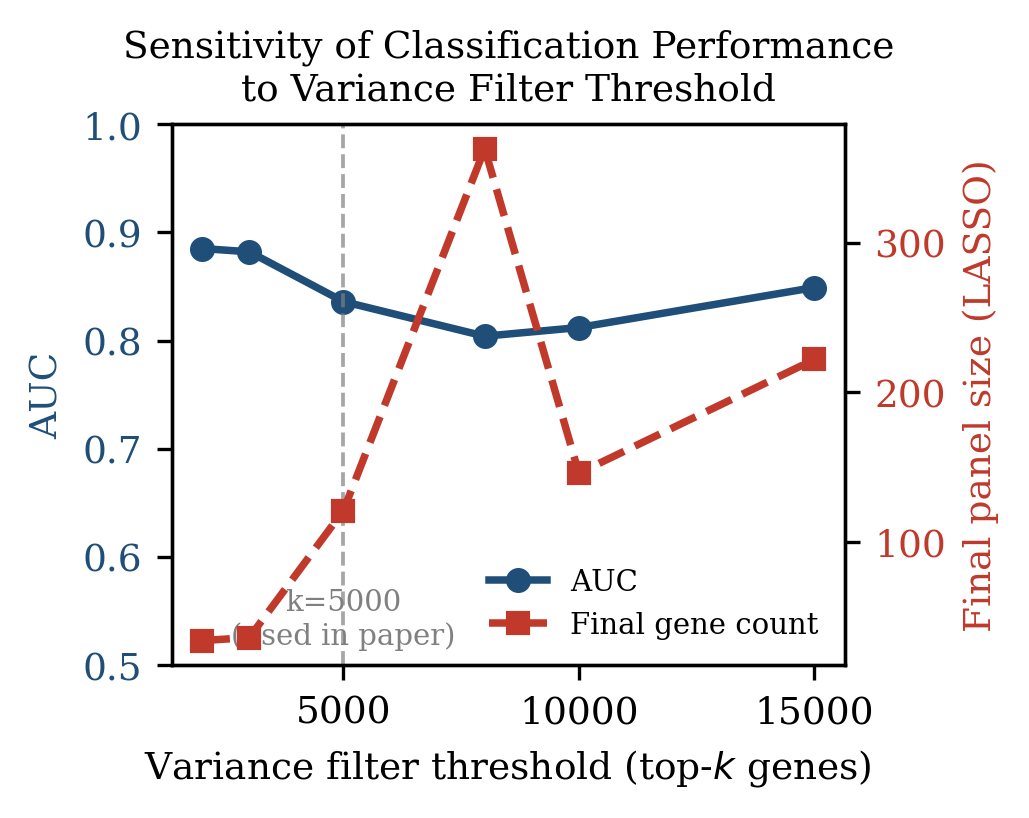

In [163]:
# ============================================================
# رسم نمودار مقایسه‌ی top_k های مختلف
# (برای استفاده مستقیم به‌عنوان Figure در مقاله‌ی IEEE)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# تنظیمات ظاهری مناسب برای مقاله‌ی علمی (فونت Serif شبیه Times)
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 9
mpl.rcParams['axes.linewidth'] = 0.8

fig, ax1 = plt.subplots(figsize=(3.5, 2.8), dpi=300)  # عرض مناسب یک ستون IEEE

x = sensitivity_df['top_k (variance)']

# ---- محور اول (چپ): AUC ----
color1 = '#1f4e79'  # آبی تیره
ax1.plot(x, sensitivity_df['AUC'], marker='o', color=color1,
         linewidth=1.8, markersize=5, label='AUC')
ax1.set_xlabel('Variance filter threshold (top-$k$ genes)')
ax1.set_ylabel('AUC', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0.5, 1.0)

# خط راهنما برای نشان دادن مقدار انتخاب‌شده در مقاله (k=5000)
if 5000 in x.values:
    ax1.axvline(x=5000, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
    ax1.text(5000, 0.52, 'k=5000\n(used in paper)',
             fontsize=7, ha='center', color='gray')

# ---- محور دوم (راست): تعداد ژن نهایی بعد از LASSO ----
ax2 = ax1.twinx()
color2 = '#c0392b'  # قرمز آجری
ax2.plot(x, sensitivity_df['N after LASSO'], marker='s', color=color2,
         linewidth=1.8, markersize=5, linestyle='--', label='Final gene count')
ax2.set_ylabel('Final panel size (LASSO)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# ---- عنوان و legend ترکیبی ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='lower right', fontsize=7, frameon=False)

plt.title('Sensitivity of Classification Performance\nto Variance Filter Threshold', fontsize=9)
plt.tight_layout()

# ---- ذخیره با کیفیت بالا برای LaTeX ----
plt.savefig('variance_threshold_sensitivity.png', dpi=300, bbox_inches='tight')
plt.savefig('variance_threshold_sensitivity.pdf', bbox_inches='tight')  # نسخه‌ی وکتور، کیفیت بهتر در LaTeX

plt.show()